# Case Study 2: Customer Churn Analysis (Python/Pandas Edition)

**Data Source:** Kaggle – Telco Customer Churn Dataset
**File:** Telco-Customer-Churn.csv
**Columns:** CustomerID, Gender, SeniorCitizen, Partner, Dependents, Tenure, PhoneService, InternetService, Contract, MonthlyCharges, TotalCharges, Churn (Yes/No)

**Goal:** Use Python to identify key factors influencing customer churn (why customers leave), and apply statistical analysis to support business retention strategies.

task 1

Open Telco-Customer-Churn.csv and use filtering to count how many customers have Churn = 'Yes' and how many have Churn = 'No'.

In [1]:
import pandas as pd

df = pd.read_csv("Telco-Customer-Churn.csv")

churned_yes = df[df["Churn"] == "Yes"]
churned_no = df[df["Churn"] == "No"]

print(f"Number of customers with Churn = 'Yes': {len(churned_yes)}")
print(f"Number of customers with Churn = 'No': {len(churned_no)}")


Number of customers with Churn = 'Yes': 133
Number of customers with Churn = 'No': 167


task 2

Analyze the relationship between Contract type (Month-to-month, One year, Two year) and Churn — show the count of churned customers for each contract type.

In [2]:
contract_vs_churn = pd.crosstab(df["Contract"], df["Churn"])

print(contract_vs_churn)

print("\nCount of CHURNED customers for each contract type:")
print(contract_vs_churn["Yes"])


Churn           No  Yes
Contract               
Month-to-month  77   97
One year        56   23
Two year        34   13

Count of CHURNED customers for each contract type:
Contract
Month-to-month    97
One year          23
Two year          13
Name: Yes, dtype: int64


task 3

Calculate the average MonthlyCharges for customers who churned versus those who did not.

In [3]:
avg_monthly_charges_churned = df[df["Churn"] == "Yes"]["MonthlyCharges"].mean()
avg_monthly_charges_not_churned = df[df["Churn"] == "No"]["MonthlyCharges"].mean()

print(f"Average MonthlyCharges (Churned = Yes): {round(avg_monthly_charges_churned, 2)}")
print(f"Average MonthlyCharges (Churned = No): {round(avg_monthly_charges_not_churned, 2)}")


Average MonthlyCharges (Churned = Yes): 62.96
Average MonthlyCharges (Churned = No): 58.2


task 4

Create a bar chart that compares the number of churned vs non-churned customers for each InternetService type (DSL, Fiber optic, No).

Churn            No  Yes
InternetService         
DSL              51   30
Fiber optic      71   73
No               45   30


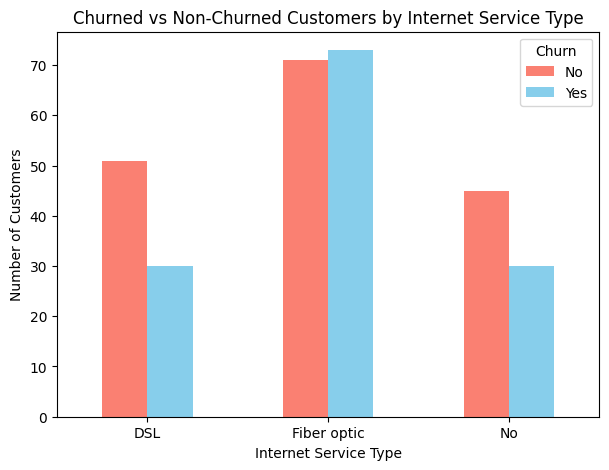

In [4]:
import matplotlib.pyplot as plt

internet_vs_churn = pd.crosstab(df["InternetService"], df["Churn"])
print(internet_vs_churn)

internet_vs_churn.plot(kind="bar", figsize=(7, 5), color=["salmon", "skyblue"])
plt.title("Churned vs Non-Churned Customers by Internet Service Type")
plt.xlabel("Internet Service Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()


task 5

Check if there is a correlation between Tenure and Churn (convert Churn 'Yes' to 1 and 'No' to 0 in a new column first), and interpret the result.

In [5]:
df["Churn_Numeric"] = df["Churn"].apply(lambda x: 1 if x == "Yes" else 0)

correlation = df["Tenure"].corr(df["Churn_Numeric"])

print(f"Correlation between Tenure and Churn: {round(correlation, 4)}")

if correlation < 0:
    interpretation = "Negative correlation: customers with longer tenure tend to churn less."
else:
    interpretation = "Positive correlation: customers with longer tenure tend to churn more."

print(f"Interpretation: {interpretation}")


Correlation between Tenure and Churn: -0.2799
Interpretation: Negative correlation: customers with longer tenure tend to churn less.
